In [1]:
# TODO 
# Simplify the input to be just the drift instead of ILD, ABL
# Simplify the list of parameters, so when we do model fitting, only the unique parameters are passed 
# (i.e. the same t_motor, zero sensory delay for the PA, etc)

import numpy as np
import matplotlib.pyplot as plt
from model_tach_4delays_v1 import model_tach_4delays
import timeit


abl= 40.
ild= 2.
t_fix= 400.
tt=np.arange(-t_fix,1000., 1)

# params are:

x = [0.1661,  # compressive_power
     31.3836,  # a_tied
     1.1275,  # T0
     0.1086,  # v
     82.2049,  # a
     40.,  # tse_TIED
     30.,  # tmotor_TIED
     -50.,  # tse_PA
     30.,  # tmotor_PA
     0.,  # Delta
     0.0034227695,  # b
     0.,  # c
     1.0,  # d
     False,  # full_readout
     False]  # use_Delta

ndt_TIED = x[5]+x[6]
tse_TIED = x[5]
tmotor_TIED = x[6]

# model = model_tach_shift(ABL=abl,ILD=ild,t_fix=t_fix)
# initialize the model
model = model_tach_4delays(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=1.0*np.ones_like(tt))
model.set_params(x)
model.print_params()

# pdf_a, tach = model.pdf_and_tach(x,v,a,abl*np.ones_like(tt),ild*np.ones_like(tt),tt,t_fix*np.ones_like(tt),w_tse,-tse+10)
# pdf_a, tach = model.pdf_and_tach(x, v, a, w_tse, Delta) 
# testing: plot correct and error joint pdfs 
pdf_a, tach = model.pdf_and_tach()

fig, ax = plt.subplots(1,2)
fig.set_size_inches([10,5])

ax[0].plot(tt, pdf_a*tach, label='correct', color='steelblue')
ax[0].plot(tt, pdf_a*(1-tach), label='error', color='plum')
ax[0].set_xlim([-t_fix,1000])

ax[1].plot(tt, tach, label='tachometric', color='steelblue')
ax[1].plot(tse_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].plot(tmotor_TIED*np.array([1,1]),np.array([0,1]),color='k',ls='--')
ax[1].plot(ndt_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].set_xlim([-t_fix,750])
ax[1].set_ylim([.5,1])

plt.show()

# testing: log likelihood

# logL_corr, logL_err = model.log_likelihood_both()
# print(np.sum(logL_corr)) 
# print(np.sum(logL_err))

start = timeit.timeit()
logL = model.log_likelihood()
end = timeit.timeit()
print(end - start)
print(np.sum(logL))


[ 0.1661 31.3836  1.1275] [ 0.1086 82.2049] [ 40.  30. -50.  30.] [0.00342277 0.         1.        ]


AttributeError: 'model_tach_4delays' object has no attribute 'tse'

(0.5, 1.0)

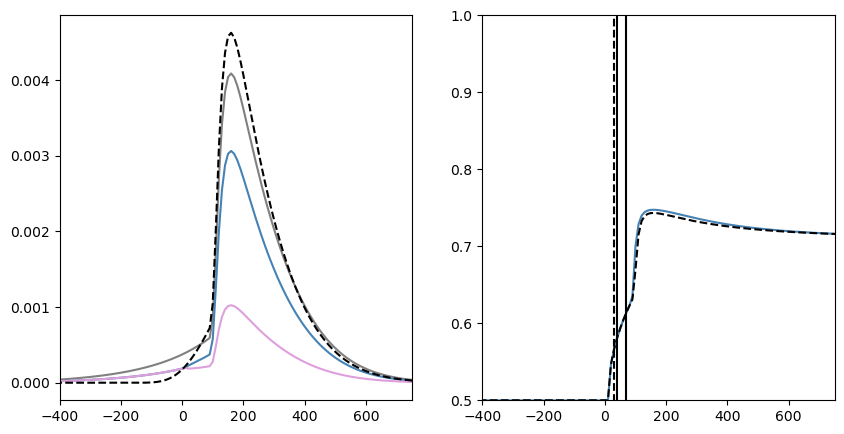

In [9]:
## Plot the pdfs and tachometric convolved

from scipy.integrate import quad_vec, simpson

ild = 2
abl = 40
out = 1.0 #outcome
t_fix = 400.

# x = [0.171142397, 30.240853, 1.22983981, 0.119605477, 92.0593483, 50., 30., 0., 0., 0.0034227695, 0.0779262977, 1.0]

# define time vector to plot the convolved pdf and tach
tt=np.arange(-700, 1000., 10)

# initialize model
t0 = tt
model = model_tach_4delays(RT=t0,ABL=abl*np.ones_like(t0),ILD=ild*np.ones_like(t0),t_fix=t_fix*np.ones_like(t0),out=out*np.ones_like(t0))
model.set_params(x)

def fun_to_integrate_pdf_and_tach(tt,t_fix):
    "This returns the pdf and tachometric multiplied by the pdf of the fixation distribution"
    model.update_data(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=out*np.ones_like(tt))  
    pdf, tach = model.pdf_and_tach()
    fix_dist = np.where(t_fix<200.,0.,np.exp(-(t_fix-200.)/200.)/200.)/(1-np.exp(-5))
    #include also correct and error pdf as 3rd and 4rd output
    return pdf*fix_dist, tach*fix_dist, pdf*tach*fix_dist, pdf*(1-tach)*fix_dist


def convolve_pdf_and_tach(tt):
    
    tfix_v = np.arange(200, 1200., 10)

    to_convolve_pdf = np.zeros((tt.size,tfix_v.size))
    to_convolve_tach = np.zeros((tt.size,tfix_v.size))
    to_convolve_pdf_cor = np.zeros((tt.size,tfix_v.size))
    to_convolve_pdf_err = np.zeros((tt.size,tfix_v.size))

    for k in range(tfix_v.size):
        to_convolve_pdf[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[0]
        to_convolve_tach[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[1]
        to_convolve_pdf_cor[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[2]
        to_convolve_pdf_err[:,k] = fun_to_integrate_pdf_and_tach(tt,tfix_v[k])[3]

    convolved_pdf = simpson(to_convolve_pdf,x=tfix_v)
    convolved_tach = simpson(to_convolve_tach,x=tfix_v)
    convolved_pdf_cor = simpson(to_convolve_pdf_cor,x=tfix_v)
    convolved_pdf_err = simpson(to_convolve_pdf_err,x=tfix_v)

    return convolved_pdf, convolved_tach, convolved_pdf_cor, convolved_pdf_err


def just_pdf_and_tach(tt,t_fix):
    "This returns just the pdf and tachometric"
    model.update_data(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=out*np.ones_like(tt))
    pdf, tach = model.pdf_and_tach()
    return pdf, tach


convolved_pdf, convolved_tach, convolved_pdf_cor, convolved_pdf_err = convolve_pdf_and_tach(tt)

just_pdf, just_tach = just_pdf_and_tach(tt,t_fix)

fig, ax = plt.subplots(1,2)
fig.set_size_inches([10,5])

ax[0].plot(tt, convolved_pdf, label='pdf all', color='gray')
ax[0].plot(tt, convolved_pdf_cor, label='pdf cor', color='steelblue')
ax[0].plot(tt, convolved_pdf_err, label='pdf err', color='plum')
ax[0].plot(tt, just_pdf, label='pdf unconvolved', color='k',ls='--')
ax[0].set_xlim([-t_fix,750])

ax[1].plot(tt, convolved_tach, label='tachometric', color='steelblue')
ax[1].plot(tt, just_tach, label='tachometric unconvolved', color='k',ls='--')
ax[1].plot(tse_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].plot(tmotor_TIED*np.array([1,1]),np.array([0,1]),color='k',ls='--')
ax[1].plot(ndt_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].set_xlim([-t_fix,750])
ax[1].set_ylim([.5,1])


In [2]:
%timeit model.log_likelihood()

2.43 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [3]:
%prun model.log_likelihood()

         299 function calls (298 primitive calls) in 0.004 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        4    0.001    0.000    0.001    0.000 model_tach_shift_v5.py:153(f_and_F_raw_all_tied)
        1    0.001    0.001    0.001    0.001 model_tach_shift_v5.py:219(acc_in_bounds_raw_withnorm)
        2    0.000    0.000    0.001    0.000 model_tach_shift_v5.py:361(f_and_F_RT_pa)
        1    0.000    0.000    0.003    0.003 model_tach_shift_v5.py:446(pdf_and_tach)
       40    0.000    0.000    0.000    0.000 model_tach_shift_v5.py:261(<lambda>)
       38    0.000    0.000    0.000    0.000 numeric.py:67(zeros_like)
        4    0.000    0.000    0.000    0.000 model_tach_shift_v5.py:383(<lambda>)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.000    0.000    0.003    0.003 model_tach_shift_v5.py:497(log_likelihood)
      2/1    0.000    0.000    0.003 

In [3]:
import numpy as np
from kreg_single import kreg_single

x1 = 1+np.random.randn((1000))
x2 = 2+np.random.randn((1000))

# RTs[0,0] = x1
# RTs[1,0] = x2

RTs = [x1,x2]

# Cs[0,0] = np.ones_like(x1)
# Cs[1,0] = np.zeros_like(x2)

Cs = [np.ones_like(x1),np.zeros_like(x2)]

# Define other necessary inputs
dx = 0.01
# Calculate xbin
xbin = np.arange(-4, dx * (np.ceil(7 / dx) + 10), dx)
xbin = xbin.T
# Calculate xxi
xxi = np.arange(-4, 7000 + 10, 10) / 1000
h = 0.01
RTmin = -4
B = 1000

print(xbin.shape, xxi.shape)

# Call the function
RTD, TCM = kreg_single(RTs, Cs, xxi, xbin, h, RTmin, B)

# Output the results
print("RTD:", RTD)
print("TCM:", TCM)





(1111,) (702,)


ValueError: operands could not be broadcast together with shapes (702,) (1111,) 